# BERT Topic Detector - Експеримент B (без класу новини)

## Архітектура класифікаційної голови на базі mBERT:
- **Head A**: `[CLS] -> Dropout -> Linear(768->num_classes)`

### Ключові параметри:
- MAX_LEN = 256, BATCH_SIZE = 8 (6GB VRAM)
- DROPOUT = 0.4, LR = 1e-5, WEIGHT_DECAY = 0.01
- Gradient Clipping max_norm=1.0
- Збереження найкращої моделі за val_f1

In [1]:
## 1. Імпорти та налаштування
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizerFast,
    BertModel,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

import gc
import json
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Device: {device}')

torch.cuda.empty_cache()
gc.collect()

PyTorch: 2.5.1+cu121
CUDA: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM: 6.4 GB
Device: cuda


109

In [2]:
## 2. Гіперпараметри
# Шляхи
DATA_PATH   = r'C:\Users\igrew\OneDrive\Desktop\Course Work\Datasets\theme_detector\ua_news_train_balanced.csv'
MODELS_DIR  = 'models/07'
PLOTS_DIR   = 'plots/07'
RESULTS_DIR = 'results'

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

assert os.path.exists(DATA_PATH), f'Датасет не знайдено: {DATA_PATH}'

# Модель
MODEL_NAME    = 'bert-base-multilingual-cased'
MAX_LEN       = 256
BATCH_SIZE    = 16
NUM_EPOCHS    = 3
LEARNING_RATE = 1e-5
WEIGHT_DECAY  = 0.01
WARMUP_RATIO  = 0.1
DROPOUT_RATE  = 0.4
GRADIENT_CLIP = 1.0
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('Гіперпараметри:')
print(f'  MAX_LEN={MAX_LEN} | BATCH_SIZE={BATCH_SIZE} | EPOCHS={NUM_EPOCHS}')
print(f'  LR={LEARNING_RATE} | DROPOUT={DROPOUT_RATE} | CLIP={GRADIENT_CLIP}')

Гіперпараметри:
  MAX_LEN=256 | BATCH_SIZE=16 | EPOCHS=3
  LR=1e-05 | DROPOUT=0.4 | CLIP=1.0


## 3. Завантаження та аналіз датасету (ExpB без новини)

In [3]:
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['text', 'target'])

print(f'Повний датасет: {df.shape}')
print('Повний розподіл тем:')
print(df['target'].value_counts())

df = df[df['target'] != 'новини'].copy()
df = df.reset_index(drop=True)

print('\nExpB (без класу новини):')
print(f'Розмір датасету: {df.shape}')
print('Розподіл тем:')
print(df['target'].value_counts())

df['text_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print('\nОпис довжин тексту:')
print(df[['text_len', 'word_count']].describe().round(1))

Повний датасет: (50000, 4)
Повний розподіл тем:
target
політика      10000
спорт         10000
новини        10000
технології    10000
бізнес        10000
Name: count, dtype: int64

ExpB (без класу новини):
Розмір датасету: (40000, 4)
Розподіл тем:
target
політика      10000
спорт         10000
технології    10000
бізнес        10000
Name: count, dtype: int64

Опис довжин тексту:
       text_len  word_count
count   40000.0     40000.0
mean     1701.7       239.0
std      2044.5       288.7
min         2.0         1.0
25%       670.0        95.0
50%      1102.0       154.0
75%      1858.0       260.0
max     61268.0      8027.0


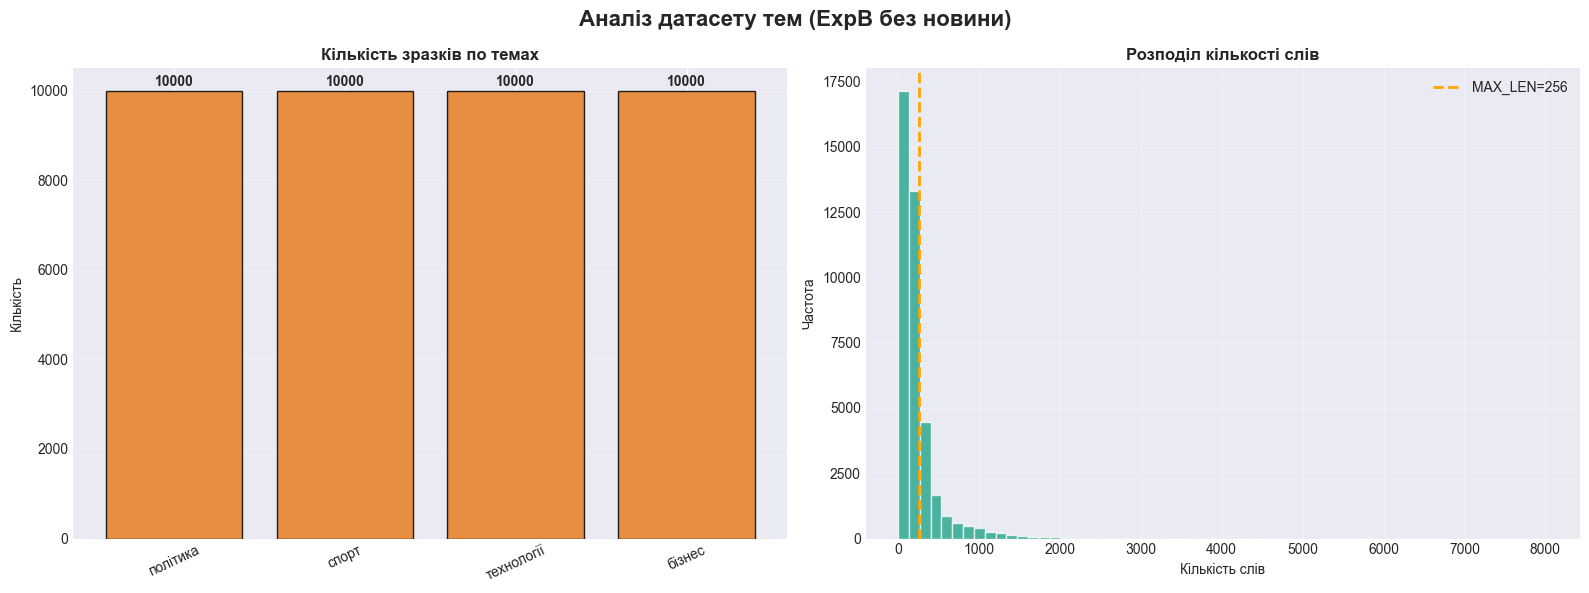


Текстів довших за 256 слів: 25.5%


In [4]:
topic_counts = df['target'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Аналіз датасету тем (ExpB без новини)', fontsize=16, fontweight='bold')

axes[0].bar(topic_counts.index, topic_counts.values, color='#e67e22', edgecolor='black', alpha=0.85)
axes[0].set_title('Кількість зразків по темах', fontweight='bold')
axes[0].set_ylabel('Кількість')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(topic_counts.values):
    axes[0].text(i, v + max(5, int(0.01 * v)), str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(df['word_count'], bins=60, color='#16a085', alpha=0.75, edgecolor='white')
axes[1].axvline(x=MAX_LEN, color='orange', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Розподіл кількості слів', fontweight='bold')
axes[1].set_xlabel('Кількість слів')
axes[1].set_ylabel('Частота')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'topic_expb_dataset_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

pct_over = (df['word_count'] > MAX_LEN).mean() * 100
print(f'\nТекстів довших за {MAX_LEN} слів: {pct_over:.1f}%')

In [5]:
## 4. Split та токенізація
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['target'])
class_names = label_encoder.classes_
num_classes = len(class_names)

X = df['text'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
 )
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
 )

print(f'Train:      {len(X_train):>6} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Validation: {len(X_val):>6} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test:       {len(X_test):>6} ({len(X_test)/len(X)*100:.1f}%)')
print(f'Класи ExpB ({num_classes}): {list(class_names)}')

tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
print(f'\nТокенізатор: {type(tokenizer).__name__}')
print(f'Розмір словника: {tokenizer.vocab_size:,}')

Train:       28000 (70.0%)
Validation:   6000 (15.0%)
Test:         6000 (15.0%)
Класи ExpB (4): ['бізнес', 'політика', 'спорт', 'технології']

Токенізатор: BertTokenizer
Розмір словника: 119,547


## 5. Dataset та DataLoader

In [6]:
class TopicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

train_dataset = TopicDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = TopicDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset  = TopicDataset(X_test, y_test, tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train: {len(train_loader)} батчів × {BATCH_SIZE} = {len(train_dataset)} зразків')
print(f'Val:   {len(val_loader)} батчів')
print(f'Test:  {len(test_loader)} батчів')

Train: 1750 батчів × 16 = 28000 зразків
Val:   375 батчів
Test:  375 батчів


## 6. Архітектура моделі (тільки Head A)

In [7]:
# HEAD A - Baseline: [CLS] -> Dropout -> Linear
class BertTopicClassifierHeadA(nn.Module):
    def __init__(self, bert_model_name, num_classes, dropout=0.4):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        hidden = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, num_classes)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(self.dropout(cls))

print('Архітектура визначена:')
print(f'  Head A: BERT -> [CLS] -> Dropout -> Linear(768->{num_classes})')

Архітектура визначена:
  Head A: BERT -> [CLS] -> Dropout -> Linear(768->4)


## 7. Функції тренування та оцінки

In [8]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='  Train', leave=False):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, train_loader, val_loader, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1 = 0
    best_path = os.path.join(MODELS_DIR, f'bert_topic_expb_{model_name.lower()}_best.pt')

    print(f'\nТренування {model_name}...')
    print(f'   Кроків warmup: {warmup_steps} / {total_steps}')
    print('=' * 75)
    print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>8} | {"Val Acc":>7} | {"Val F1":>6}')
    print('=' * 75)

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, criterion)
        val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        flag = ''
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), best_path)
            flag = ' ✓ SAVED'

        delta = val_loss - train_loss
        print(f'{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.4f} | {val_loss:>8.4f} | {val_acc:>7.4f} | {val_f1:>6.4f}  Δ={delta:+.4f}{flag}')

    print('=' * 75)
    print(f'Найкращий Val F1: {best_val_f1:.4f}')
    model.load_state_dict(torch.load(best_path, map_location=device))
    return model, history, best_val_f1

print('Функції тренування визначено')

Функції тренування визначено


## 8. Функції візуалізації

In [9]:
def plot_head_results(head_name, history, y_true, y_pred, y_prob, metrics, class_names):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Результати {head_name} (ExpB)', fontsize=16, fontweight='bold')

    axes[0, 0].plot(epochs, history['train_loss'], 'o-', color='#e67e22', label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 's--', color='#f5b041', label='Val', linewidth=2)
    axes[0, 0].set_title('Loss', fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], 'o-', color='#e67e22', label='Train', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 's--', color='#f5b041', label='Val', linewidth=2)
    axes[0, 1].set_title('Accuracy', fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_ylim([0.3, 1.0])
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    deltas = [v - t for v, t in zip(history['val_loss'], history['train_loss'])]
    bar_colors = ['#e74c3c' if d > 0.05 else '#2ecc71' for d in deltas]
    axes[0, 2].bar(epochs, deltas, color=bar_colors, alpha=0.8)
    axes[0, 2].axhline(y=0.05, color='orange', linestyle='--', linewidth=1.5, label='Поріг 0.05')
    axes[0, 2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    axes[0, 2].set_title('Δ Val-Train Loss по епохах', fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Val Loss - Train Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3, axis='y')

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', ax=axes[1, 0], cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, linewidths=1, linecolor='white'
    )
    axes[1, 0].set_title(f'Confusion Matrix (Acc={metrics["acc"]:.3f})', fontweight='bold')
    axes[1, 0].set_xlabel('Передбачено')
    axes[1, 0].set_ylabel('Реальне')

    y_true_bin = label_binarize(y_true, classes=np.arange(len(class_names)))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        axes[1, 1].plot(fpr, tpr, lw=1.5, label=f'{cls} (AUC={auc_i:.3f})')
    axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[1, 1].set_title('ROC Curve (OvR)', fontweight='bold')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(alpha=0.3)

    metric_names = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']
    metric_values = [metrics['acc'], metrics['f1'], metrics['prec'], metrics['rec'], metrics['roc_auc']]
    bars = axes[1, 2].bar(metric_names, metric_values, color='#e67e22', alpha=0.8)
    axes[1, 2].set_ylim([0, 1.05])
    axes[1, 2].set_title('Метрики на тестовій вибірці', fontweight='bold')
    axes[1, 2].grid(alpha=0.3, axis='y')
    for bar, val in zip(bars, metric_values):
        axes[1, 2].text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 0.005,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(PLOTS_DIR, f'bert_topic_expb_{head_name.lower()}_results.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Збережено: {save_path}')

print('Функції візуалізації визначено')

Функції візуалізації визначено


## 9. Тренування Head A (Topic ExpB)

HEAD A: [CLS] -> Dropout -> Linear


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Параметрів: 177,856,516

Тренування HeadA...
   Кроків warmup: 525 / 5250
 Epoch | Train Loss | Train Acc | Val Loss | Val Acc | Val F1


     1 |     0.2713 |   0.9005 |   0.1148 |  0.9723 | 0.9723  Δ=-0.1565 ✓ SAVED


     2 |     0.0860 |   0.9795 |   0.0959 |  0.9775 | 0.9775  Δ=+0.0099 ✓ SAVED


     3 |     0.0440 |   0.9898 |   0.1108 |  0.9800 | 0.9800  Δ=+0.0669 ✓ SAVED
Найкращий Val F1: 0.9800

Test Results Head A (Topic ExpB):
  acc: 0.9772
  f1: 0.9772
  prec: 0.9772
  rec: 0.9772
  roc_auc: 0.9983


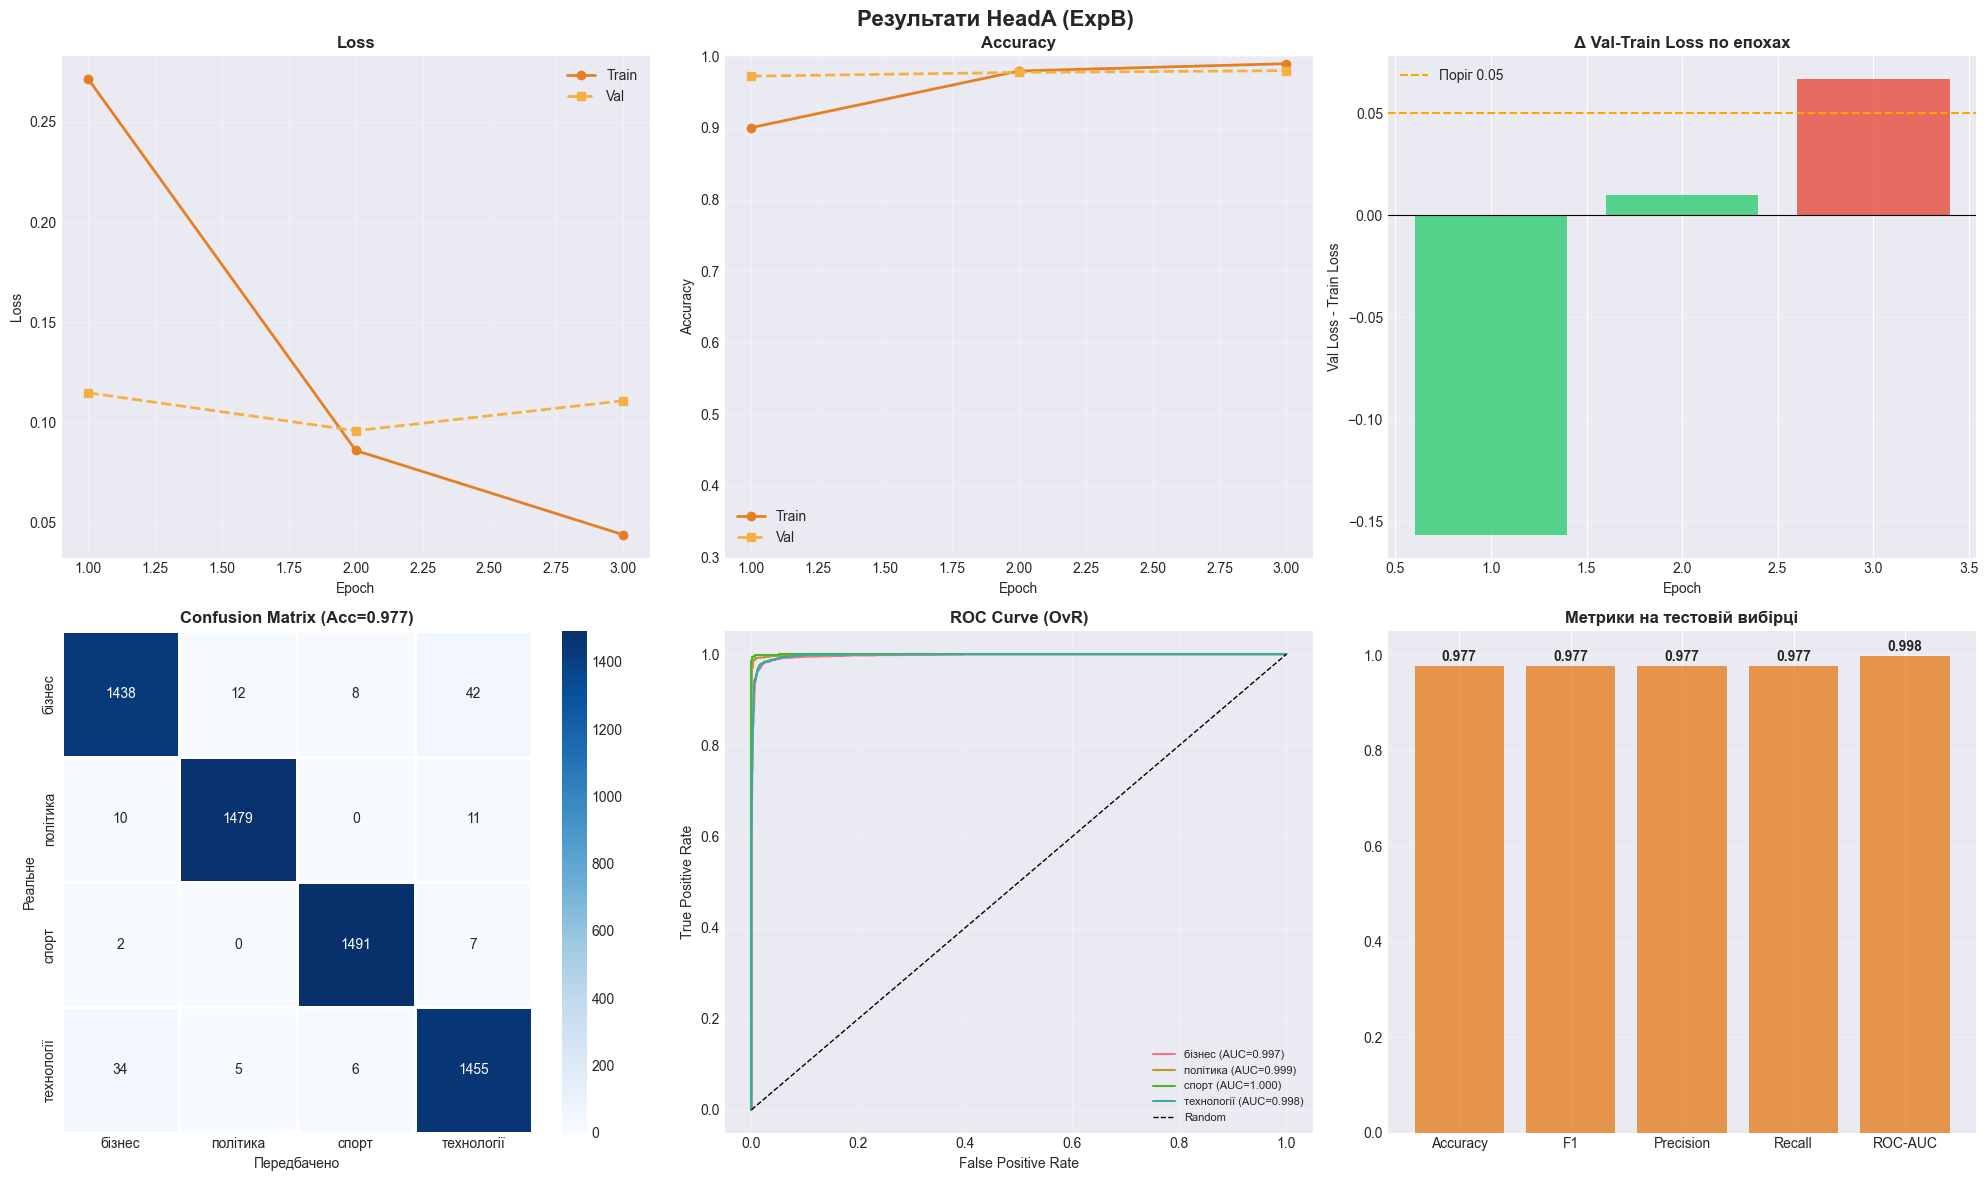

Збережено: plots/07\bert_topic_expb_heada_results.png


In [10]:
torch.cuda.empty_cache()
gc.collect()

print('=' * 60)
print('HEAD A: [CLS] -> Dropout -> Linear')
print('=' * 60)

model_a = BertTopicClassifierHeadA(MODEL_NAME, num_classes=num_classes, dropout=DROPOUT_RATE).to(device)
print(f'Параметрів: {sum(p.numel() for p in model_a.parameters()):,}')

model_a, history_a, best_f1_a = train_model(model_a, train_loader, val_loader, 'HeadA')
criterion = nn.CrossEntropyLoss()
_, _, _, y_true_a, y_pred_a, y_prob_a = evaluate(model_a, test_loader, criterion)

metrics_a = {
    'acc': accuracy_score(y_true_a, y_pred_a),
    'f1': f1_score(y_true_a, y_pred_a, average='weighted', zero_division=0),
    'prec': precision_score(y_true_a, y_pred_a, average='weighted', zero_division=0),
    'rec': recall_score(y_true_a, y_pred_a, average='weighted', zero_division=0),
    'roc_auc': roc_auc_score(
        label_binarize(y_true_a, classes=np.arange(num_classes)),
        y_prob_a,
        multi_class='ovr',
        average='weighted'
    )
}

print('\nTest Results Head A (Topic ExpB):')
for k, v in metrics_a.items():
    print(f'  {k}: {v:.4f}')

plot_head_results('HeadA', history_a, y_true_a, y_pred_a, y_prob_a, metrics_a, class_names)

## 10. Додаткові графіки тренування

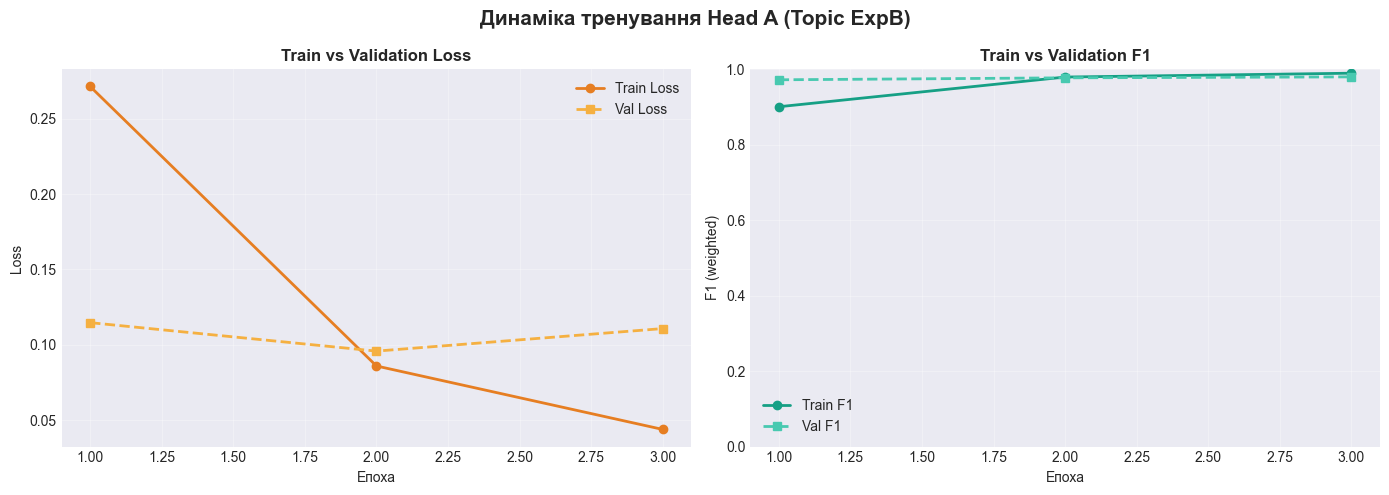

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Динаміка тренування Head A (Topic ExpB)', fontsize=15, fontweight='bold')

epochs = range(1, NUM_EPOCHS + 1)
axes[0].plot(epochs, history_a['train_loss'], 'o-', color='#e67e22', label='Train Loss', linewidth=2)
axes[0].plot(epochs, history_a['val_loss'], 's--', color='#f5b041', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Епоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history_a['train_f1'], 'o-', color='#16a085', label='Train F1', linewidth=2)
axes[1].plot(epochs, history_a['val_f1'], 's--', color='#48c9b0', label='Val F1', linewidth=2)
axes[1].set_xlabel('Епоха')
axes[1].set_ylabel('F1 (weighted)')
axes[1].set_ylim([0.0, 1.0])
axes[1].set_title('Train vs Validation F1', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bert_topic_expb_heada_training.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Classification Report та F1 по темах

CLASSIFICATION REPORT (Head A, Topic ExpB)
              precision    recall  f1-score   support

      бізнес     0.9690    0.9587    0.9638      1500
    політика     0.9886    0.9860    0.9873      1500
       спорт     0.9907    0.9940    0.9923      1500
  технології     0.9604    0.9700    0.9652      1500

    accuracy                         0.9772      6000
   macro avg     0.9772    0.9772    0.9772      6000
weighted avg     0.9772    0.9772    0.9772      6000



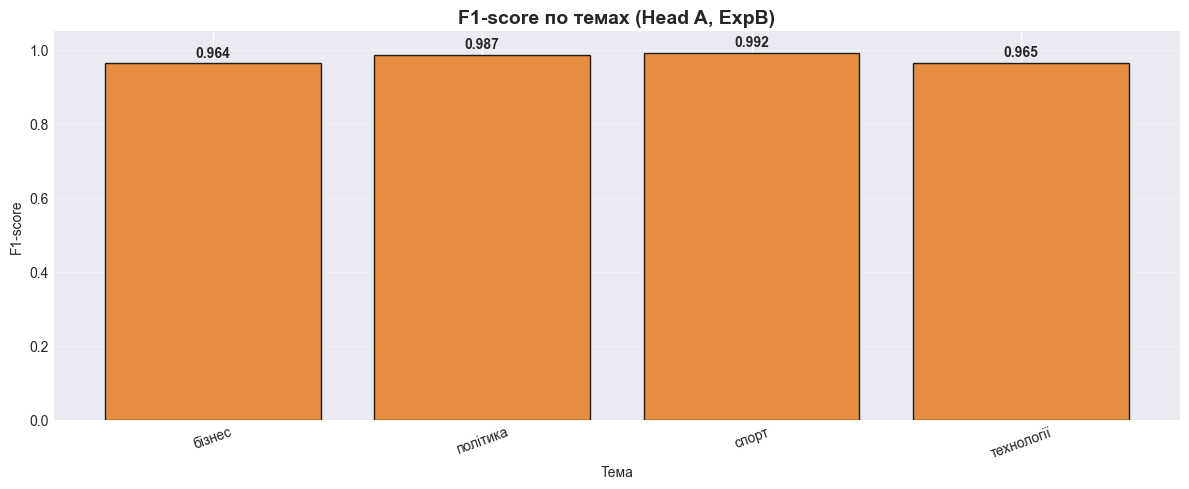

In [12]:
print('=' * 80)
print('CLASSIFICATION REPORT (Head A, Topic ExpB)')
print('=' * 80)
print(classification_report(y_true_a, y_pred_a, target_names=class_names, digits=4, zero_division=0))

report = classification_report(
    y_true_a,
    y_pred_a,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)
per_class_f1 = [report[c]['f1-score'] for c in class_names]

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, per_class_f1, color='#e67e22', alpha=0.85, edgecolor='black')
plt.ylim(0, 1.05)
plt.title('F1-score по темах (Head A, ExpB)', fontsize=14, fontweight='bold')
plt.xlabel('Тема')
plt.ylabel('F1-score')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width() / 2.0, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bert_topic_expb_heada_f1_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Збереження моделі та результатів

In [13]:
best_name = 'Head A (Linear)'

torch.save({
    'model_state_dict': model_a.state_dict(),
    'model_name': MODEL_NAME,
    'head_type': best_name,
    'max_len': MAX_LEN,
    'num_classes': num_classes,
    'class_names': list(class_names),
    'test_accuracy': metrics_a['acc'],
    'test_f1': metrics_a['f1'],
    'hyperparameters': {
        'max_len': MAX_LEN,
        'dropout': DROPOUT_RATE,
        'lr': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'weight_decay': WEIGHT_DECAY,
        'gradient_clip': GRADIENT_CLIP
    }
}, os.path.join(MODELS_DIR, 'bert_topic_expb_detector_best.pt'))

tokenizer.save_pretrained(os.path.join(MODELS_DIR, 'bert_tokenizer'))
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

metrics_to_save = {
    'metrics': {
        'accuracy': float(metrics_a['acc']),
        'precision': float(metrics_a['prec']),
        'recall': float(metrics_a['rec']),
        'f1': float(metrics_a['f1']),
        'roc_auc_ovr_weighted': float(metrics_a['roc_auc'])
    },
    'model_name': '07_BERT_Topic_ExpB_HeadA',
    'experiment': 'ExpB_without_новини',
    'classes': list(class_names),
    'hyperparameters': {
        'max_len': MAX_LEN,
        'batch_size': BATCH_SIZE,
        'epochs': NUM_EPOCHS,
        'lr': LEARNING_RATE,
        'dropout': DROPOUT_RATE,
        'weight_decay': WEIGHT_DECAY
    }
}

result_path = os.path.join(RESULTS_DIR, '07_bert_topic_expB_results.json')
with open(result_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)

print('Збережено:')
print(f'  {os.path.join(MODELS_DIR, "bert_topic_expb_detector_best.pt")}')
print(f'  {os.path.join(MODELS_DIR, "bert_tokenizer")}')
print(f'  {os.path.join(MODELS_DIR, "label_encoder.pkl")}')
print(f'  {result_path}')

Збережено:
  models/07\bert_topic_expb_detector_best.pt
  models/07\bert_tokenizer
  models/07\label_encoder.pkl
  results\07_bert_topic_expB_results.json


## 13. Підсумкова таблиця та висновки

In [14]:
print('\n' + '=' * 80)
print('ПІДСУМКОВА ТАБЛИЦЯ')
print('=' * 80)
print(f'{"Модель":<30} {"Acc":>8} {"F1":>8} {"Prec":>8} {"Rec":>8} {"AUC":>8}')
print('-' * 80)
print(f'{"BERT Topic ExpB Head A":<30} {metrics_a["acc"]:>8.4f} {metrics_a["f1"]:>8.4f} {metrics_a["prec"]:>8.4f} {metrics_a["rec"]:>8.4f} {metrics_a["roc_auc"]:>8.4f}')
print('=' * 80)

print('\nНайкраща архітектура: Head A (єдина у цьому експерименті)')
print(f'  Accuracy: {metrics_a["acc"]:.4f}')
print(f'  F1-Score: {metrics_a["f1"]:.4f}')
print(f'  ROC-AUC:  {metrics_a["roc_auc"]:.4f}')

print('\nЕксперимент 07 приведений до структури Exp 02/06, адаптовано під ExpB без класу новини.')


ПІДСУМКОВА ТАБЛИЦЯ
Модель                              Acc       F1     Prec      Rec      AUC
--------------------------------------------------------------------------------
BERT Topic ExpB Head A           0.9772   0.9772   0.9772   0.9772   0.9983

Найкраща архітектура: Head A (єдина у цьому експерименті)
  Accuracy: 0.9772
  F1-Score: 0.9772
  ROC-AUC:  0.9983

Експеримент 07 приведений до структури Exp 02/06, адаптовано під ExpB без класу новини.


### Висновок: структура, порядок і логіка коду узгоджені з базовим BERT-експериментом, але для ExpB (4 теми, без новини) і тільки з Head A.


📊 Аналіз найбільших помилок між темами...


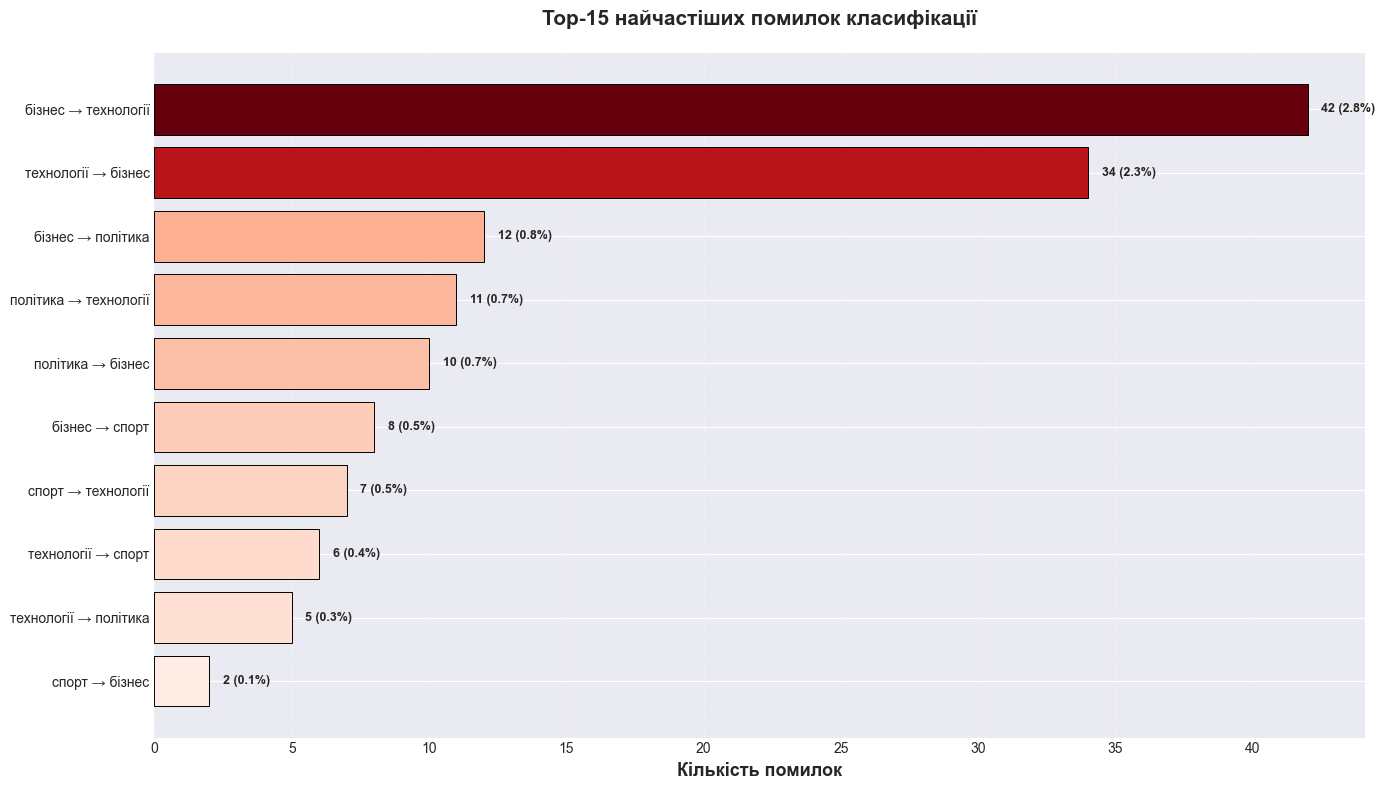


🔍 Топ-5 найчастіших помилок:
1. 'бізнес' плутається з 'технології': 42 разів (2.8%)
2. 'технології' плутається з 'бізнес': 34 разів (2.3%)
3. 'бізнес' плутається з 'політика': 12 разів (0.8%)
4. 'політика' плутається з 'технології': 11 разів (0.7%)
5. 'політика' плутається з 'бізнес': 10 разів (0.7%)


In [15]:
print("\n📊 Аналіз найбільших помилок між темами...")

cm = confusion_matrix(y_true_a, y_pred_a)
unique_classes = class_names
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

errors = []
for i in range(len(unique_classes)):
    for j in range(len(unique_classes)):
        if i != j and cm[i][j] > 0:
            errors.append({
                'True': unique_classes[i],
                'Predicted': unique_classes[j],
                'Count': cm[i][j],
                'Percentage': cm_normalized[i][j] * 100
            })

df_errors = pd.DataFrame(errors).sort_values('Count', ascending=False).head(15)

plt.figure(figsize=(14, 8))
y_pos = range(len(df_errors))
colors = plt.cm.Reds(df_errors['Count'] / df_errors['Count'].max())

bars = plt.barh(y_pos, df_errors['Count'], color=colors, edgecolor='black', linewidth=0.7)
plt.yticks(y_pos, [f"{row['True']} → {row['Predicted']}" for _, row in df_errors.iterrows()], fontsize=10)
plt.xlabel('Кількість помилок', fontsize=13, weight='bold')
plt.title('Top-15 найчастіших помилок класифікації', fontsize=15, weight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.gca().invert_yaxis()

for i, (idx, row) in enumerate(df_errors.iterrows()):
    plt.text(row['Count'] + 0.5, i, f"{row['Count']} ({row['Percentage']:.1f}%)", 
             va='center', fontsize=9, weight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 Топ-5 найчастіших помилок:")
for i, (idx, row) in enumerate(df_errors.head(5).iterrows(), 1):
    print(f"{i}. '{row['True']}' плутається з '{row['Predicted']}': {row['Count']} разів ({row['Percentage']:.1f}%)")